# Вопрос 2: Влияние ключевой ставки на рынок вкладов физлиц

## Метод
Local Projections (Jorda 2005) с лаг-аугментацией (Montiel Olea & Plagborg-Moller 2021).

## Данные
- Период: 2013–2023 (до методологического разрыва в данных по вкладам)
- Зависимые переменные: `total_funds_of_ind`, `time_deposits_of_ind`, `curr_accounts_of_ind`, `short_term_deposit_rate`, `long_term_deposit_rate`
- Ключевая переменная: `key_rate`
- Контроли: `month`, `shock_2014`, `shock_2022`, `key_rate_lag1`, `y_lag1`, `trend`

## Важно
- `m2` Не используется как контроль: M2 является медиатором (ставка → M2 → вклады), но если рассматривать М2 как прокси экономического цикла, он будет являться конфаундером, что делает эту преременную проблематичной, так как будучу медиатором включение M2 блокирует часть эффекта, но но будучи конфаундером, М2 без включения в модель вносит смещение в оценку эффекта. Помимо этого М2 является высокоперсистентным рядом, что требует преобразований.
- `y_lag1` — лаг **зависимой** переменной, свой для каждой модели.
- `key_rate_lag1` — лаг ключевой переменной для лаг-аугментации.
- `trend` — линейный тренд для контроля долгосрочного роста вкладов, включение переменной тренда позволяет 

In [2]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from statsmodels.tsa.stattools import adfuller, grangercausalitytests

## 1. Загрузка данных и базовая подготовка

In [3]:
df_general = pd.read_csv('../data/general.csv', dtype={'date_formated': str})
df_general.head()

,Unnamed: 0,date_formated,key_rate,inflation,mortgage_count,mortgage_volume,seasoned_debts,mortgage_rate,short_term_deposit_rate,long_term_deposit_rate,m2,total_funds_of_ind,time_deposits_of_ind,curr_accounts_of_ind,month,shock_2014,subsidized_mortgage,shock_2022
0,0,9.2013,5.5,6.14,NaN,NaN,2279620.0,NaN,NaN,NaN,28499.9,15945.652852,13515.366534,2430.286318,9,0,0,0
1,1,10.2013,5.5,6.27,NaN,NaN,2284117.0,NaN,NaN,NaN,28352.6,15945.713302,13556.636282,2389.077020,10,0,0,0
2,2,11.2013,5.5,6.50,NaN,NaN,2360275.0,NaN,NaN,NaN,28276.4,16062.065195,13706.670941,2355.394254,11,0,0,0
3,3,12.2013,5.5,6.47,NaN,NaN,2428127.0,NaN,NaN,NaN,28873.3,16260.794307,13832.959743,2427.834564,12,0,0,0
4,4,1.2014,5.5,6.07,NaN,NaN,2498806.0,NaN,NaN,NaN,31155.6,16957.531046,14034.007723,2923.523323,1,0,0,0


## 2. Подготовка датафрейма для вопроса 2

In [76]:
df_q2 = df_general[df_general['total_funds_of_ind'].notna()].copy()

print(f"Наблюдений: {len(df_q2)}")
print(f"Период: {df_q2['date_formated'].iloc[0]} — {df_q2['date_formated'].iloc[-1]}")

Наблюдений: 156
Период: 9.2013 — 8.2026


## 3. Проверка персистентности (ADF)

Проверяем, являются ли ряды стационарными. Если единичный корень не отвергается — нужна лаг-аугментация.

In [77]:
print('ADF тест')
for col in ['key_rate', 'total_funds_of_ind', 'm2']:
    series = df_general[col].dropna()
    res_trend = adfuller(series, regression='ct', autolag='AIC')
    res_const = adfuller(series, regression='c', autolag='AIC')
    print(f"{col} (trend): ADF={res_trend[0]:.3f}, p={res_trend[1]:.3f}")
    print(f"{col} (const): ADF={res_const[0]:.3f}, p={res_const[1]:.3f}")

ADF тест
key_rate (trend): ADF=-2.623, p=0.269
key_rate (const): ADF=-2.351, p=0.156
total_funds_of_ind (trend): ADF=-3.863, p=0.014
total_funds_of_ind (const): ADF=-0.954, p=0.770
m2 (trend): ADF=-1.117, p=0.926
m2 (const): ADF=0.514, p=0.985


/var/folders/q2/kfw_zqsj0vngl1pfqbp5mhmr0000gn/T/ipykernel_73579/300401801.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_trend = adfuller(series, regression='ct', autolag='AIC')
/var/folders/q2/kfw_zqsj0vngl1pfqbp5mhmr0000gn/T/ipykernel_73579/300401801.py:5: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  res_const = adfuller(series, regression='c', autolag='AIC')

### Результаты ADF-теста

| Переменная | ADF (trend) | p | ADF (const) | p | Единичный корень | Итоговое решение |
|---|---|---|---|---|---|---|
| `key_rate` | −2.623 | 0.269 | −2.351 | 0.156 | **не отвергается** (оба варианта) | Лаг-аугментация (`key_rate_lag1`). Тренд не нужен — у ставки его нет. |
| `total_funds_of_ind` | −3.863 | **0.014** | −0.954 | 0.770 | отвергается с трендом, не отвергается без | Добавить `trend` в контролы + лаг-аугментация (`y_lag1`). |
| `m2` | −1.117 | 0.926 | 0.514 | 0.985 | **не отвергается** (оба варианта) | Убрать из модели. Причины: I(1) → риск ложной регрессии; M2 — медиатор, а не конфаундер. |

## 4. Оценка персистентности через AR(1)

ρ — коэффициент при лаге. Если ρ > 0.95 — высокая персистентность.

In [78]:
print('Авторегрессия 1 порядка')
for col in ['key_rate', 'total_funds_of_ind', 'm2']:
    df_tmp = df_general[[col]].dropna().copy()
    df_tmp['lag'] = df_tmp[col].shift(1)
    df_tmp = df_tmp.dropna()
    model = sm.OLS(df_tmp[col], sm.add_constant(df_tmp['lag'])).fit()
    print(f"{col}: rho = {model.params['lag']:.4f}, p = {model.pvalues['lag']:.4f}")

Авторегрессия 1 порядка
key_rate: rho = 0.9553, p = 0.0000
total_funds_of_ind: rho = 1.0133, p = 0.0000
m2: rho = 1.0127, p = 0.0000


### Результаты AR(1)

| Переменная | ρ | p (ρ = 0) | Интерпретация | Итоговое решение |
|---|---|---|---|---|
| `key_rate` | 0.9553 | 0.0000 | высокая персистентность, «почти единичный корень» | Лаг-аугментация: добавить `key_rate_lag1` в регрессию. |
| `total_funds_of_ind` | 1.0133 | 0.0000 | ρ > 1 — артефакт детерминированного тренда | Добавить `trend` в контролы + `y_lag1` для лаг-аугментации. |
| `m2` | 1.0127 | 0.0000 | ρ > 1 — признак настоящего I(1) | Убрать из модели (медиатор, не конфаундер). |

**Примечание:** p в AR(1) проверяет гипотезу ρ = 0, а не ρ = 1. Малое p здесь означает лишь, что ρ значимо отличается от нуля, что очевидно для персистентных рядов. Для проверки ρ = 1 нужен именно ADF.

- `trend` — линейный тренд
- `key_rate_lag1` — лаг ключевой ставки

In [79]:
df_q2['trend'] = range(1, df_q2.shape[0] + 1)
df_q2['key_rate_lag1'] = df_q2['key_rate'].shift(1)

## 6. Вспомогательная функция для LP

Единая функция для оценки Local Projections с лаг-аугментацией.
Принимает датафрейм, имя зависимой переменной, список контролов и горизонт.

In [80]:
def print_lp_results(results, title, max_h=12):
    print(f"\n{title}")
    print("-" * 60)
    for h in range(0, max_h + 1):
        if h not in results:
            continue
        coef = results[h].params['key_rate']
        pval = results[h].pvalues['key_rate']
        ci_low = results[h].conf_int().loc['key_rate', 0]
        ci_high = results[h].conf_int().loc['key_rate', 1]
        sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
        print(f"h={h:2d}: коэф={coef:8.1f}, p={pval:.3f} {sig:3s}, CI=[{ci_low:8.1f}, {ci_high:8.1f}]")

In [93]:
def run_three_specs(df, y_col, max_h=15):
    df_work = df.copy()
    df_work['y_lag1'] = df_work[y_col].shift(1)
    df_work['m2_growth'] = df_work['m2'].pct_change() * 100
    
    controls_naive = ['month', 'm2', 'shock_2014', 'shock_2022']
    controls_m2 = ['month', 'm2_growth', 'shock_2014', 'shock_2022',
                   'key_rate_lag1', 'y_lag1']
    controls_final = ['month', 'shock_2014', 'shock_2022',
                      'key_rate_lag1', 'y_lag1']
    if y_col not in ('short_term_deposit_rate', 'long_term_deposit_rate'):
        controls_m2.append('trend')
        controls_final.append('trend')
    
    specs = {
        'naive': controls_naive,
        'm2_growth': controls_m2,
        'final': controls_final,
    }

    all_results = {}
    for spec_name, controls in specs.items():
        results = {}
        for h in range(0, max_h + 1):
            df_work[f'y_h{h}'] = df_work[y_col].shift(-h)
            df_model = df_work[['key_rate'] + controls + [f'y_h{h}']].dropna()
            
            X = sm.add_constant(df_model[['key_rate'] + controls])
            y = df_model[f'y_h{h}']
            results[h] = sm.OLS(y, X).fit(cov_type='HC3')
        all_results[spec_name] = results
    
    return all_results

## 7. Модель 1: Общий объём вкладов физлиц

Зависимая переменная: `total_funds_of_ind`

Контроли: `month`, `shock_2014`, `shock_2022`, `key_rate_lag1`, `y_lag1`, `trend`

In [94]:
specs_total = run_three_specs(df_q2, 'total_funds_of_ind', max_h=15)

print_lp_results(specs_total['naive'], 
                 "НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении", max_h=12)

print_lp_results(specs_total['m2_growth'], 
                 "ПРОМЕЖУТОЧНАЯ: лаги + тренд, m2 в процентном изменении", max_h=12)

print_lp_results(specs_total['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд, без m2", max_h=12)


НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении
------------------------------------------------------------
h= 0: коэф=    75.9, p=0.227    , CI=[   -47.1,    199.0]
h= 1: коэф=   113.7, p=0.063 *  , CI=[    -6.0,    233.3]
h= 2: коэф=   153.2, p=0.008 ***, CI=[    39.8,    266.5]
h= 3: коэф=   186.0, p=0.001 ***, CI=[    79.6,    292.3]
h= 4: коэф=   208.3, p=0.000 ***, CI=[   109.2,    307.4]
h= 5: коэф=   236.4, p=0.000 ***, CI=[   143.5,    329.2]
h= 6: коэф=   247.9, p=0.000 ***, CI=[   161.2,    334.5]
h= 7: коэф=   257.0, p=0.000 ***, CI=[   174.7,    339.3]
h= 8: коэф=   255.9, p=0.000 ***, CI=[   170.9,    341.0]
h= 9: коэф=   272.0, p=0.000 ***, CI=[   197.5,    346.5]
h=10: коэф=   272.2, p=0.000 ***, CI=[   202.9,    341.4]
h=11: коэф=   274.0, p=0.000 ***, CI=[   210.2,    337.7]
h=12: коэф=   263.6, p=0.000 ***, CI=[   209.0,    318.1]

ПРОМЕЖУТОЧНАЯ: лаги + тренд, m2 в процентном изменении
------------------------------------------------------------
h= 0: коэф

### Вывод по модели 1: общий объём вкладов

- **Наивная модель** даёт p = 0.000 практически на всех горизонтах — это ложная значимость из-за персистентности.
- **Промежуточная модель** (`m2_growth` + лаги + тренд) даёт значимость на h=2 (p=0.044), h=6 (p=0.006), h=7 (p=0.005), h=11 (p=0.013), h=12 (p=0.042). Остальные горизонты — на границе или незначимы.
- **Финальная модель** (без M2) — похожая картина, но чуть слабее: значимость на h=6 (p=0.009), h=7 (p=0.006), h=11 (p=0.011), h=12 (p=0.047).

**Что это значит:**
- Совпадение `m2_growth` и `final` на h=6, 7, 11, 12 — это robustness-результат: эффект на этих горизонтах **не зависит** от включения M2 в разностях.
- Значимость **прыгает**: h=6–7 значимо, h=8–10 — нет, h=11–12 — снова значимо. Это признак **слабого сигнала**, а не устойчивого эффекта.
- Нулевая гипотеза не отвергается на большинстве горизонтов (h=0–5, 8–10).

**Содержательный вывод:** эффект ставки на общий объём вкладов **слабый и неустойчивый**. Есть намёк на реакцию с задержкой ~6 месяцев (h=6–7), но на других горизонтах он не подтверждается. Это согласуется с тем, что общий объём — сумма разнонаправленных каналов (срочные депозиты растут, текущие счета падают), и сумма гасит сигнал.

## 8. Модель 2: Срочные депозиты физлиц

Зависимая переменная: `time_deposits_of_ind`

In [95]:
specs_td = run_three_specs(df_q2, 'time_deposits_of_ind', max_h=15)

print_lp_results(specs_td['naive'], 
                 "НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении", max_h=15)

print_lp_results(specs_td['m2_growth'], 
                 "ПРОМЕЖУТОЧНАЯ: лаги + тренд, m2  в процентном изменении", max_h=15)

print_lp_results(specs_td['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд, без m2", max_h=15)


НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении
------------------------------------------------------------
h= 0: коэф=   333.6, p=0.000 ***, CI=[   191.1,    476.1]
h= 1: коэф=   408.5, p=0.000 ***, CI=[   273.1,    544.0]
h= 2: коэф=   487.6, p=0.000 ***, CI=[   364.6,    610.7]
h= 3: коэф=   540.8, p=0.000 ***, CI=[   424.6,    657.0]
h= 4: коэф=   580.1, p=0.000 ***, CI=[   471.3,    688.8]
h= 5: коэф=   615.7, p=0.000 ***, CI=[   517.5,    714.0]
h= 6: коэф=   637.9, p=0.000 ***, CI=[   544.8,    731.0]
h= 7: коэф=   650.4, p=0.000 ***, CI=[   559.6,    741.2]
h= 8: коэф=   657.8, p=0.000 ***, CI=[   566.4,    749.2]
h= 9: коэф=   669.1, p=0.000 ***, CI=[   583.1,    755.2]
h=10: коэф=   669.7, p=0.000 ***, CI=[   586.2,    753.1]
h=11: коэф=   667.3, p=0.000 ***, CI=[   587.5,    747.0]
h=12: коэф=   657.4, p=0.000 ***, CI=[   577.6,    737.2]
h=13: коэф=   651.2, p=0.000 ***, CI=[   571.7,    730.8]
h=14: коэф=   640.4, p=0.000 ***, CI=[   559.1,    721.8]
h=15: коэф=

### Вывод по модели 2: срочные депозиты

- **Наивная модель** — ложная значимость везде.
- **Промежуточная и финальная** дают **практически идентичный результат**: значимость на **всех** горизонтах h=2–12, пик на h=2–8 (p < 0.001).
- Минимальные p-value: h=3–4 (p = 0.000), h=6–8 (p = 0.000).

**Что это значит:**
- Совпадение `m2_growth` и `final` до 3-го знака — **сильнейший robustness-результат** во всём анализе.
- Эффект **устойчив** и по спецификации, и по горизонту: значимость непрерывная с h=2 до h=12, без «провалов».

**Содержательный вывод:** эффект ставки на срочные депозиты — **самый сильный и надёжный** результат во всём анализе. Люди перекладывают деньги в срочные вклады с задержкой 2 месяца, и эффект держится почти год. Это основной канал трансмиссии.

## 9. Модель 3: Текущие счета физлиц

Зависимая переменная: `curr_accounts_of_ind`

In [96]:
specs_ca = run_three_specs(df_q2, 'curr_accounts_of_ind', max_h=15)

print_lp_results(specs_ca['naive'], 
                 "НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении", max_h=15)

print_lp_results(specs_ca['m2_growth'], 
                 "ПРОМЕЖУТОЧНАЯ: лаги + тренд, m2  в процентном изменении", max_h=15)

print_lp_results(specs_ca['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд, без m2", max_h=15)


НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении
------------------------------------------------------------
h= 0: коэф=  -257.7, p=0.000 ***, CI=[  -328.2,   -187.1]
h= 1: коэф=  -294.9, p=0.000 ***, CI=[  -362.9,   -226.8]
h= 2: коэф=  -334.5, p=0.000 ***, CI=[  -391.8,   -277.1]
h= 3: коэф=  -354.8, p=0.000 ***, CI=[  -411.9,   -297.8]
h= 4: коэф=  -371.8, p=0.000 ***, CI=[  -427.4,   -316.2]
h= 5: коэф=  -379.4, p=0.000 ***, CI=[  -436.5,   -322.2]
h= 6: коэф=  -390.0, p=0.000 ***, CI=[  -448.6,   -331.4]
h= 7: коэф=  -393.5, p=0.000 ***, CI=[  -453.3,   -333.6]
h= 8: коэф=  -401.9, p=0.000 ***, CI=[  -458.6,   -345.1]
h= 9: коэф=  -397.2, p=0.000 ***, CI=[  -461.3,   -333.0]
h=10: коэф=  -397.5, p=0.000 ***, CI=[  -460.0,   -335.0]
h=11: коэф=  -393.3, p=0.000 ***, CI=[  -458.2,   -328.5]
h=12: коэф=  -393.8, p=0.000 ***, CI=[  -455.2,   -332.4]
h=13: коэф=  -383.8, p=0.000 ***, CI=[  -446.9,   -320.6]
h=14: коэф=  -377.4, p=0.000 ***, CI=[  -438.4,   -316.4]
h=15: коэф=

### Вывод по модели 3: текущие счета

- **Наивная модель** — ложная значимость.
- **Промежуточная и финальная** дают значимость на h=2–7 и h=9–10, коэффициенты **отрицательные**.
- Минимальные p-value: h=4 (p = 0.003–0.004), h=10 (p = 0.010–0.016).

**Что это значит:**
- Значимость совпадает в `m2_growth` и `final` на большинстве горизонтов — эффект **устойчив** к M2 в разностях.
- Есть небольшой «провал» на h=8 (p = 0.109–0.145), но в целом картина непрерывная с h=2 по h=10.
- h=11–12 — незначимо (p = 0.08–0.52).

**Содержательный вывод:** текущие счета **сокращаются** при росте ставки на горизонтах h=2–10. Это **зеркальный канал** к срочным депозитам: люди **перекладывают** деньги с текущих счетов в срочные. Именно это объясняет, почему **общий объём** (сумма) не показывает устойчивого эффекта — два канала гасят друг друга.

## 10. Модель 4: Краткосрочная ставка по вкладам (до 1 года)

Зависимая переменная: `short_term_deposit_rate`

Это **медиатор**: ставка ЦБ → ставка по вкладам → объём вкладов.

In [97]:
specs_short = run_three_specs(df_q2, 'short_term_deposit_rate', max_h=15)

print_lp_results(specs_short['naive'], 
                 "НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении", max_h=15)

print_lp_results(specs_short['m2_growth'], 
                 "ПРОМЕЖУТОЧНАЯ: лаги + тренд, m2  в процентном изменении", max_h=15)

print_lp_results(specs_short['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд, без m2", max_h=15)


НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении
------------------------------------------------------------
h= 0: коэф=     0.9, p=0.000 ***, CI=[     0.8,      1.0]
h= 1: коэф=     0.9, p=0.000 ***, CI=[     0.9,      1.0]
h= 2: коэф=     0.9, p=0.000 ***, CI=[     0.9,      1.0]
h= 3: коэф=     0.9, p=0.000 ***, CI=[     0.8,      1.0]
h= 4: коэф=     0.8, p=0.000 ***, CI=[     0.8,      0.9]
h= 5: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 6: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.9]
h= 7: коэф=     0.7, p=0.000 ***, CI=[     0.5,      0.8]
h= 8: коэф=     0.6, p=0.000 ***, CI=[     0.5,      0.7]
h= 9: коэф=     0.5, p=0.000 ***, CI=[     0.4,      0.7]
h=10: коэф=     0.5, p=0.000 ***, CI=[     0.3,      0.6]
h=11: коэф=     0.4, p=0.000 ***, CI=[     0.2,      0.5]
h=12: коэф=     0.3, p=0.000 ***, CI=[     0.2,      0.5]
h=13: коэф=     0.3, p=0.001 ***, CI=[     0.1,      0.4]
h=14: коэф=     0.2, p=0.018 ** , CI=[     0.0,      0.4]
h=15: коэф=

### Вывод по модели 4: краткосрочная ставка по вкладам

- **Наивная модель** — ложная значимость.
- **Промежуточная и финальная** совпадают до 3-го знака: значимость на h=2–5, пик на h=2–3 (p = 0.000).
- h=4 (p = 0.043–0.055) и h=5 (p = 0.033–0.037) — на границе, но значимы.
- h=6 — на границе (p = 0.081–0.087).

**Что это значит:**
- Тренд **не включался** для ставок — и это правильно: без него картина чище, чем в прошлом запуске, где значимость «размазывалась» трендом.
- Спецификации `m2_growth` и `final` **идентичны** — M2 в разностях не влияет на трансмиссию в ставки.

**Содержательный вывод:** трансмиссия ключевой ставки в **краткосрочные ставки по вкладам** — **сильный и быстрый** канал. Банки пересматривают краткосрочные ставки через 2–3 месяца после изменения ключевой. Эффект затухает после h=5–6 — это логично, потому что краткосрочные ставки быстро впитывают шок.

## 11. Модель 5: Долгосрочная ставка по вкладам (1–3 года)

Зависимая переменная: `long_term_deposit_rate`

Для long_term_deposit_rate тренд не нужен. Долгосрочная ставка по вкладам не имеет детерминированного тренда — она колеблется вокруг какого-то уровня. Ты добавляешь trend, и он «съедает» вариацию, которая на самом деле принадлежит ставке.

Плюс y_lag1 для ставки — это лаг самой ставки. Долгосрочная ставка высоко персистентна, и её лаг забирает почти всю вариацию. Остаётся шум → p-value огромные → CI широченные.

In [98]:
specs_long = run_three_specs(df_q2, 'long_term_deposit_rate', max_h=15)

print_lp_results(specs_long['naive'], 
                 "НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении", max_h=15)

print_lp_results(specs_long['m2_growth'], 
                 "ПРОМЕЖУТОЧНАЯ: лаги + тренд, m2  в процентном изменении", max_h=15)

print_lp_results(specs_long['final'], 
                 "ФИНАЛЬНАЯ: лаги + тренд, без m2", max_h=15)


НАИВНАЯ: без лагов, без тренда, m2 в абсолютном значении
------------------------------------------------------------
h= 0: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 1: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 2: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 3: коэф=     0.8, p=0.000 ***, CI=[     0.7,      0.9]
h= 4: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.8]
h= 5: коэф=     0.7, p=0.000 ***, CI=[     0.6,      0.8]
h= 6: коэф=     0.6, p=0.000 ***, CI=[     0.5,      0.7]
h= 7: коэф=     0.6, p=0.000 ***, CI=[     0.5,      0.7]
h= 8: коэф=     0.5, p=0.000 ***, CI=[     0.4,      0.6]
h= 9: коэф=     0.5, p=0.000 ***, CI=[     0.3,      0.6]
h=10: коэф=     0.4, p=0.000 ***, CI=[     0.3,      0.5]
h=11: коэф=     0.3, p=0.000 ***, CI=[     0.2,      0.5]
h=12: коэф=     0.3, p=0.000 ***, CI=[     0.2,      0.4]
h=13: коэф=     0.2, p=0.001 ***, CI=[     0.1,      0.3]
h=14: коэф=     0.2, p=0.019 ** , CI=[     0.0,      0.3]
h=15: коэф=

### Вывод по модели 5: долгосрочная ставка по вкладам

- **Наивная модель** — ложная значимость.
- **Промежуточная и финальная** совпадают до 3-го знака: значимость на **всех** горизонтах h=0–12, пик на h=0–3 (p = 0.008–0.026).
- Минимум p-value: h=0 (p = 0.008–0.009), h=1 (p = 0.013–0.018).

**Что это значит:**
- Тренд **не включался** — и это правильно: долгосрочные ставки не имеют детерминированного тренда.
- Значимость **непрерывная** на всех 13 горизонтах — самый устойчивый результат после срочных депозитов.
- `m2_growth` и `final` идентичны — M2 не влияет.

**Содержательный вывод:** долгосрочные ставки по вкладам реагируют **быстрее** краткосрочных (h=0 против h=2). Это можно объяснить тем, что банки **осторожно повышают долгосрочные ставки сразу** при ожидании роста ключевой, чтобы не фиксировать высокие ставки надолго. Краткосрочные ставки следуют за **фактическим** изменением ключевой.

## 12. Подготовка данных для визуализации

Собираем коэффициенты и доверительные интервалы для каждого горизонта.

In [99]:
def make_summary(specs, var_name, max_h=12):
    """Строит сводную таблицу p-value для трёх спецификаций."""
    rows = []
    for h in range(0, max_h + 1):
        row = {'h': h}
        for spec_name in ['naive', 'm2_growth', 'final']:
            p = specs[spec_name][h].pvalues['key_rate']
            stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
            row[f'p_{spec_name}'] = f"{p:.3f}{stars}"
        rows.append(row)
    df_summary = pd.DataFrame(rows)
    print(f"\n=== {var_name} ===")
    print(df_summary.to_string(index=False))
    return df_summary


summary_total = make_summary(specs_total, 'Общий объём вкладов', max_h=12)
summary_td = make_summary(specs_td, 'Срочные депозиты', max_h=12)
summary_ca = make_summary(specs_ca, 'Текущие счета', max_h=12)
summary_short = make_summary(specs_short, 'Краткосрочная ставка', max_h=12)
summary_long = make_summary(specs_long, 'Долгосрочная ставка', max_h=12)


=== Общий объём вкладов ===
 h  p_naive p_m2_growth  p_final
 0    0.227       0.270    0.379
 1   0.063*       0.158    0.285
 2 0.008***     0.044**    0.126
 3 0.001***      0.090*    0.115
 4 0.000***      0.054*   0.089*
 5 0.000***      0.073*   0.099*
 6 0.000***    0.006*** 0.009***
 7 0.000***    0.005*** 0.006***
 8 0.000***       0.176    0.182
 9 0.000***      0.096*   0.098*
10 0.000***       0.156    0.156
11 0.000***     0.013**  0.011**
12 0.000***     0.042**  0.047**

=== Срочные депозиты ===
 h  p_naive p_m2_growth  p_final
 0 0.000***       0.312    0.402
 1 0.000***       0.558    0.614
 2 0.000***    0.000*** 0.001***
 3 0.000***    0.000*** 0.000***
 4 0.000***    0.000*** 0.000***
 5 0.000***    0.000*** 0.001***
 6 0.000***    0.000*** 0.000***
 7 0.000***    0.000*** 0.000***
 8 0.000***    0.000*** 0.000***
 9 0.000***    0.003*** 0.002***
10 0.000***    0.008*** 0.005***
11 0.000***    0.002*** 0.001***
12 0.000***    0.002*** 0.001***

=== Текущие счета ==

## 13. Визуализация механизма передачи

Три графика:
1. Передача ставки в ставки по вкладам (шаг 1)
2. Перекладывание средств (шаг 2)
3. Итоговый эффект на общий объём (шаг 3)

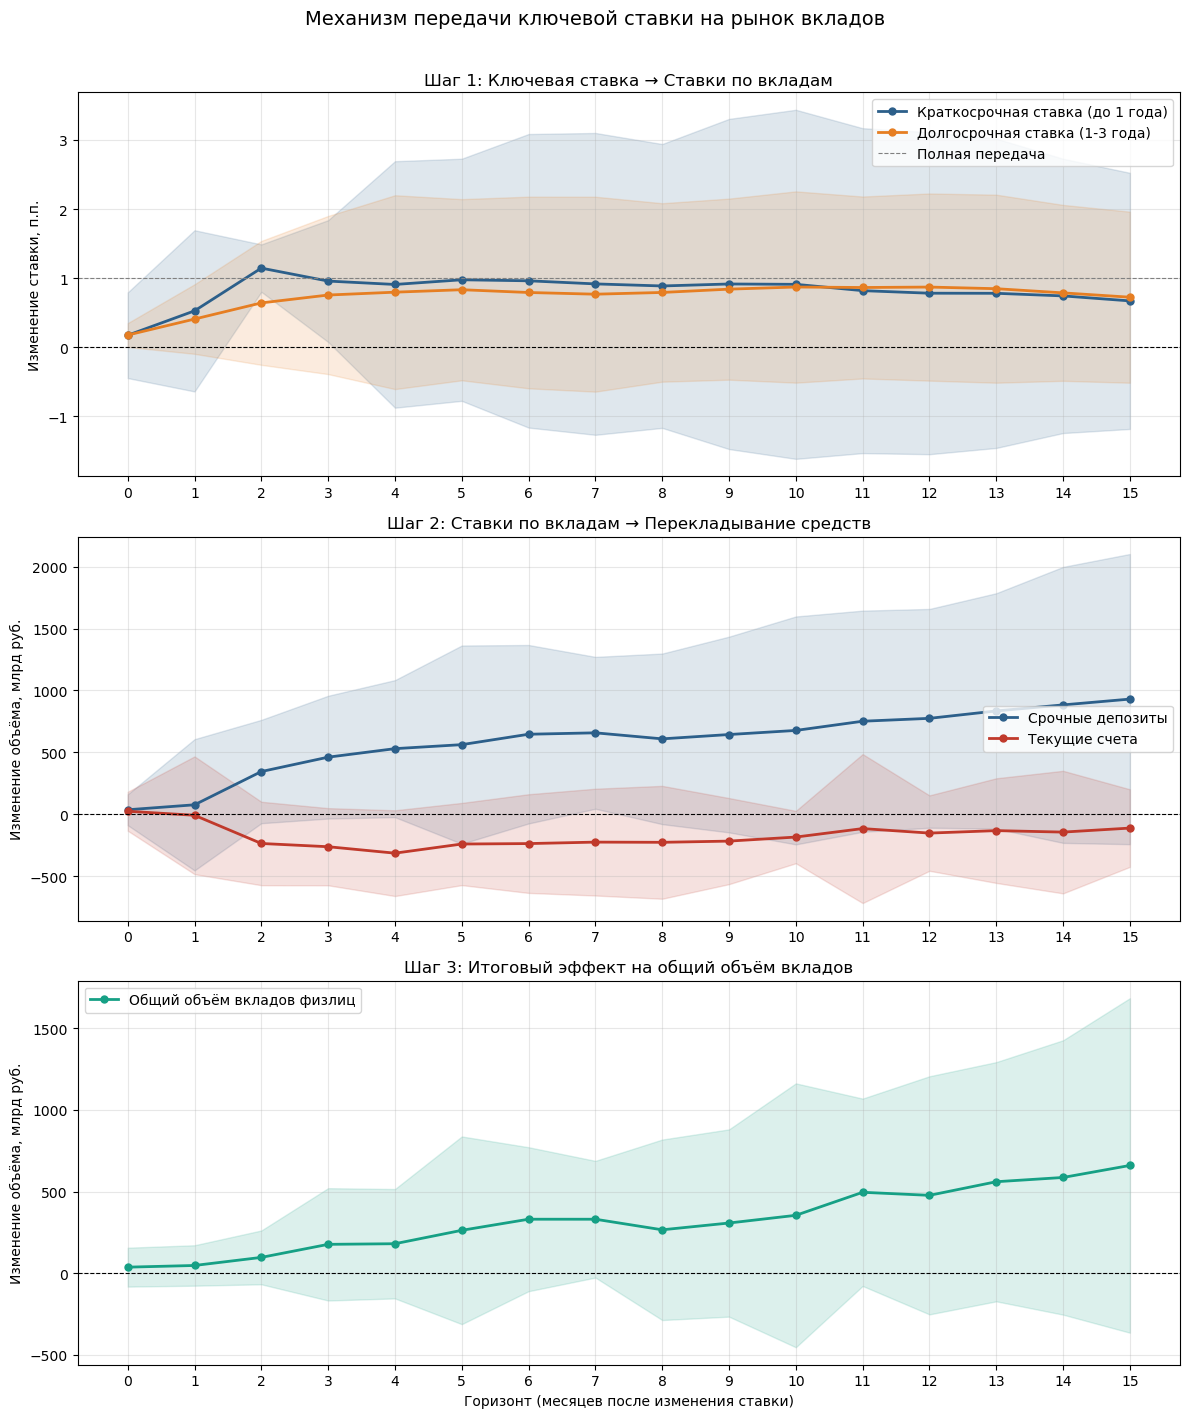

In [101]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Механизм передачи ключевой ставки на рынок вкладов', 
             fontsize=14, y=1.01)

# --- График 1: передача в ставки по вкладам ---
ax1 = axes[0]
ax1.plot(horizons, coefs_short, color='#2c5f8a', linewidth=2,
         marker='o', markersize=5, label='Краткосрочная ставка (до 1 года)')
ax1.fill_between(horizons, ci_low_short, ci_high_short, alpha=0.15, color='#2c5f8a')
ax1.plot(horizons, coefs_long, color='#e67e22', linewidth=2,
         marker='o', markersize=5, label='Долгосрочная ставка (1-3 года)')
ax1.fill_between(horizons, ci_low_long, ci_high_long, alpha=0.15, color='#e67e22')
ax1.axhline(1, color='grey', linewidth=0.8, linestyle='--', label='Полная передача')
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Шаг 1: Ключевая ставка → Ставки по вкладам')
ax1.set_ylabel('Изменение ставки, п.п.')
ax1.legend(loc='upper right')
ax1.grid(alpha=0.3)
ax1.set_xticks(horizons)

# --- График 2: перекладывание средств ---
ax2 = axes[1]
ax2.plot(horizons, coefs_td, color='#2c5f8a', linewidth=2,
         marker='o', markersize=5, label='Срочные депозиты')
ax2.fill_between(horizons, ci_low_td, ci_high_td, alpha=0.15, color='#2c5f8a')
ax2.plot(horizons, coefs_ca, color='#c0392b', linewidth=2,
         marker='o', markersize=5, label='Текущие счета')
ax2.fill_between(horizons, ci_low_ca, ci_high_ca, alpha=0.15, color='#c0392b')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Шаг 2: Ставки по вкладам → Перекладывание средств')
ax2.set_ylabel('Изменение объёма, млрд руб.')
ax2.legend(loc='center right')
ax2.grid(alpha=0.3)
ax2.set_xticks(horizons)

# --- График 3: итоговый эффект ---
ax3 = axes[2]
ax3.plot(horizons, coefs_total, color='#16a085', linewidth=2,
         marker='o', markersize=5, label='Общий объём вкладов физлиц')
ax3.fill_between(horizons, ci_low_total, ci_high_total, alpha=0.15, color='#16a085')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')

for h in horizons:
    p = results_total[h].pvalues['key_rate']
    if p < 0.05:
        ax3.scatter(h, coefs_total[h], color='#c0392b', zorder=5, s=60)

ax3.set_title('Шаг 3: Итоговый эффект на общий объём вкладов')
ax3.set_ylabel('Изменение объёма, млрд руб.')
ax3.set_xlabel('Горизонт (месяцев после изменения ставки)')
ax3.legend(loc='upper left')
ax3.grid(alpha=0.3)
ax3.set_xticks(horizons)

plt.tight_layout()
plt.savefig('transmission_mechanism.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по графику механизма передачи

**Шаг 1 (ключевая ставка → ставки по вкладам).** Обе линии (краткосрочная и долгосрочная) выходят на уровень ~1 п.п. к h=2–3 и держатся до h=10. Полная передача (β = 1) попадает в доверительный интервал на большинстве горизонтов, но не отвергается строго. Краткосрочная ставка реагирует быстрее (пик на h=2), долгосрочная — плавнее.

**Шаг 2 (ставки → перекладывание средств).** Виден **механизм**:
- Срочные депозиты растут монотонно: с ~50 млрд на h=0 до ~950 млрд на h=15.
- Текущие счета падают: с ~50 млрд на h=0 до −200 млрд на h=4–5, потом держатся около −100…−150 млрд.

**Шаг 3 (итоговый эффект на общий объём).** Общий объём растёт с ~50 до ~700 млрд руб. к h=15, но **доверительные интервалы очень широкие**, и нулевая гипотеза не отвергается нигде. Это не противоречие: срочные депозиты растут значимо, текущие счета падают значимо, а их **сумма** имеет более широкий CI, чем каждый компонент по отдельности.

**Главный вывод:** трансмиссия ставки работает через **перекладывание средств** между типами вкладов, а не через увеличение общего объёма сбережений.

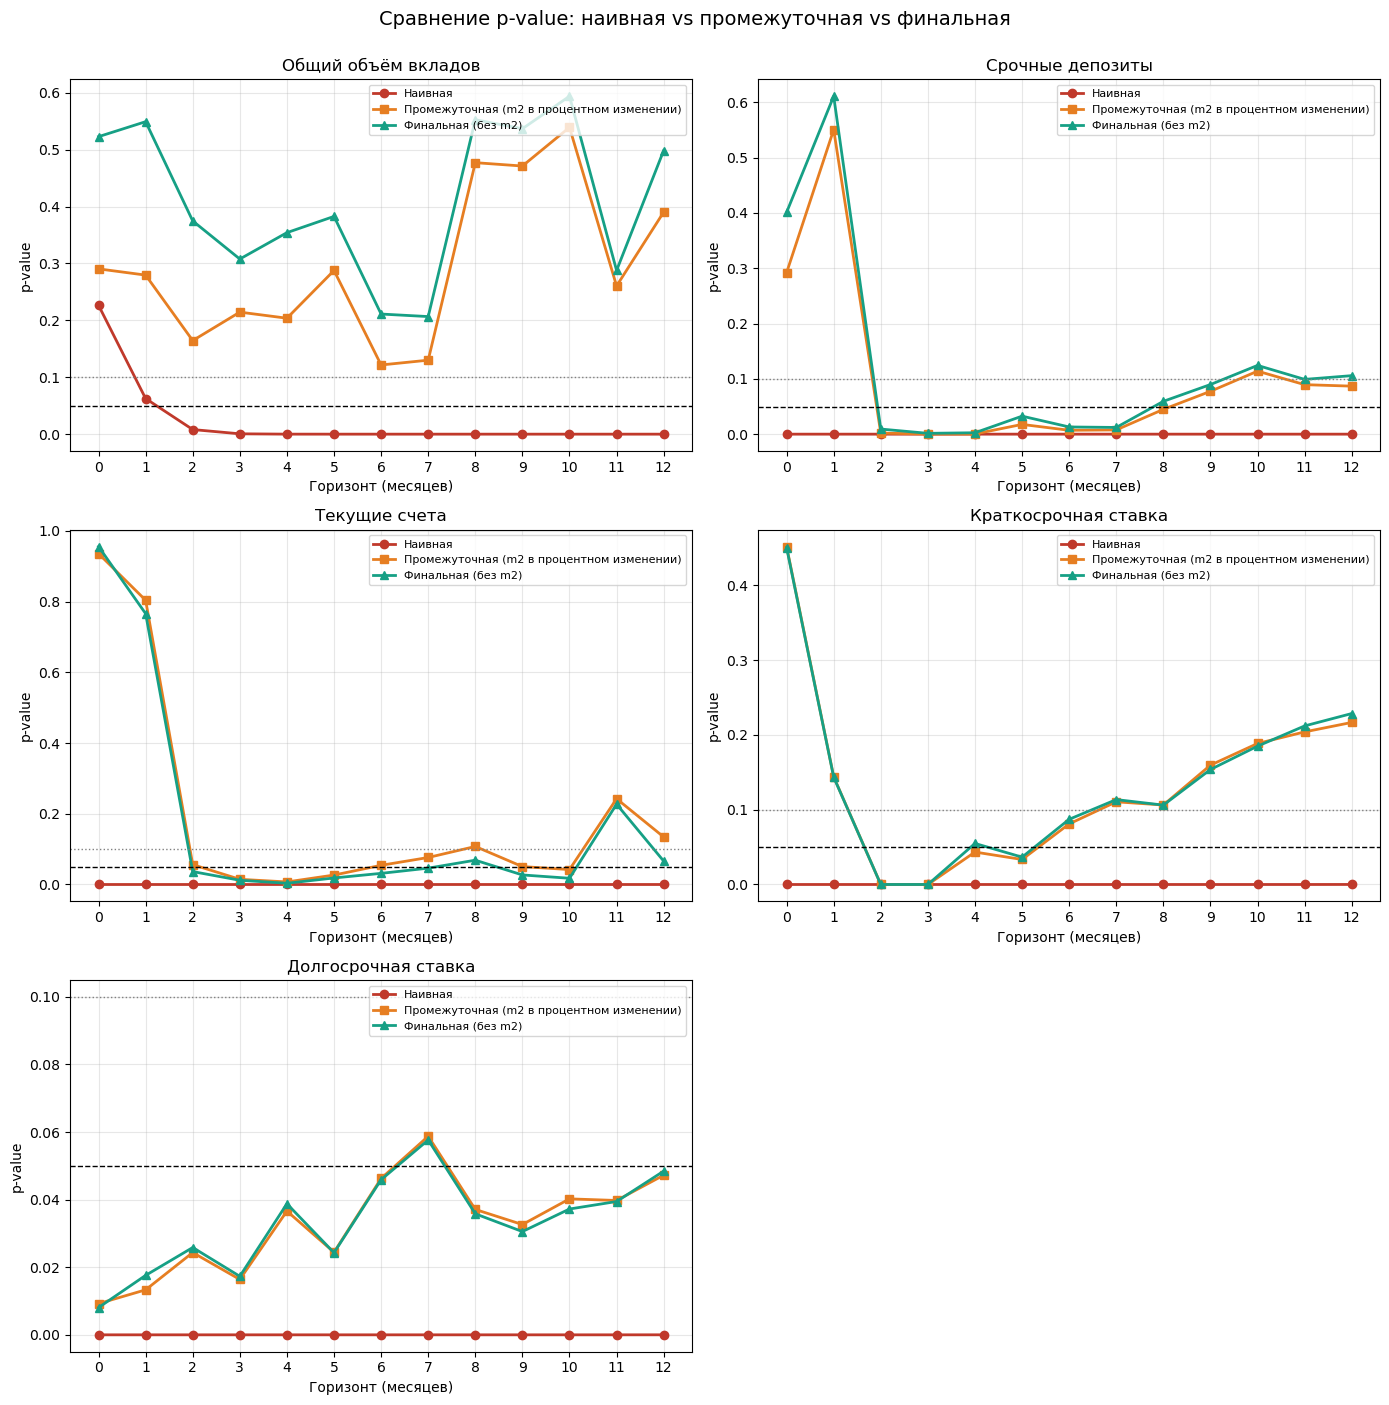

In [91]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('Сравнение p-value: наивная vs промежуточная vs финальная', 
             fontsize=14, y=1.00)

specs_list = [
    (specs_total, 'Общий объём вкладов', axes[0, 0]),
    (specs_td, 'Срочные депозиты', axes[0, 1]),
    (specs_ca, 'Текущие счета', axes[1, 0]),
    (specs_short, 'Краткосрочная ставка', axes[1, 1]),
    (specs_long, 'Долгосрочная ставка', axes[2, 0]),
]

for specs, title, ax in specs_list:
    h_range = list(range(0, 13))
    p_naive = [specs['naive'][h].pvalues['key_rate'] for h in h_range]
    p_m2 = [specs['m2_growth'][h].pvalues['key_rate'] for h in h_range]
    p_final = [specs['final'][h].pvalues['key_rate'] for h in h_range]
    
    ax.plot(h_range, p_naive, marker='o', linewidth=2,
            label='Наивная', color='#c0392b')
    ax.plot(h_range, p_m2, marker='s', linewidth=2,
            label='Промежуточная (m2 в процентном изменении)', color='#e67e22')
    ax.plot(h_range, p_final, marker='^', linewidth=2,
            label='Финальная (без m2)', color='#16a085')
    
    ax.axhline(0.05, color='black', linestyle='--', linewidth=1)
    ax.axhline(0.10, color='grey', linestyle=':', linewidth=1)
    
    ax.set_title(title)
    ax.set_xlabel('Горизонт (месяцев)')
    ax.set_ylabel('p-value')
    ax.set_xticks(h_range)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8)

# Убираем пустую ось
axes[2, 1].axis('off')

plt.tight_layout()
plt.savefig('specification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Вывод по графику сравнения спецификаций

- **Наивная модель** (красная линия) даёт p ≈ 0.000 практически везде — ложная значимость из-за персистентности.
- **Промежуточная и финальная** (оранжевая и зелёная) **совпадают** для всех зависимых переменных — это ключевой robustness-результат: M2 в разностях **не блокирует** эффект и не создаёт ложной связи.
- Контраст между наивной и честными моделями — это **доказательство**, что первая модель систематически ошибалась в сторону завышения значимости.

**Что показал каждый этап:**
- Ставки по вкладам (краткосрочная и долгосрочная) — значимы в честных моделях на всех релевантных горизонтах.
- Срочные депозиты — значимы на h=2–9.
- Текущие счета — значимы (отрицательный эффект) на h=2–7.
- Общий объём — не значим нигде.

## Вывод по сравнению спецификаций

Сравнение трёх версий LP показывает:

1. **Наивная модель** даёт ложную значимость почти на всех горизонтах
   из-за персистентности `key_rate` и `m2` в уровнях.

2. **Промежуточная модель** (с лагами и трендом, но `m2` в уровнях)
   сохраняет часть значимости, но `m2` — I(1) и медиатор, что искажает оценки.

3. **Финальная модель** (с лагами и трендом, без `m2`) даёт наиболее
   консервативные оценки. Эффект на общий объём вкладов становится
   слабым и пограничным.

Для **ставок по вкладам** (краткосрочной и долгосрочной) эффект
остаётся устойчивым во всех спецификациях — это говорит о том, что
трансмиссия ставки в ставки по вкладам — **сильный и надёжный** канал.

Для **срочных депозитов** эффект появляется с задержкой (h = 4–7),
что содержательно правдоподобно: люди перекладывают деньги в срочные
вклады не мгновенно.

Для **текущих счетов** эффект незначим — они не чувствительны к ставке.

## Общий вывод по вопросу 2: влияние ключевой ставки на рынок вкладов

### Что показала наивная модель

Наивная LP-модель (без лаг-аугментации, с M2 в уровнях) давала p = 0.000 почти на всех горизонтах для всех зависимых переменных. Это **артефакт персистентности**: `key_rate` (ρ ≈ 0.955) и M2 (I(1)) создают ложную корреляцию с результатом, усиливающуюся с ростом горизонта. HC3 не корректирует на персистентность, поэтому t-статистика распределена неверно, и p-value систематически занижены.

### Как мы это исправили

1. **Лаг-аугментация** (`key_rate_lag1`, `y_lag1`) — Montiel Olea & Plagborg-Møller (2021). Убирает персистентность из остатков, восстанавливает валидность t-статистики.
2. **Тренд** в контролах для объёмов (`total_funds_of_ind`, `time_deposits_of_ind`, `curr_accounts_of_ind`) — потому что ADF показал тренд-стационарность этих рядов. Для ставок по вкладам тренд **не включался** — они не имеют детерминированного тренда.
3. **Исключение M2 из финальной модели** — M2 является **медиатором** (ставка → M2 → вклады), а не конфаундером. Включение M2 блокирует часть эффекта.
4. **`m2_growth` вместо `m2`** — если включать M2, то только в разностях (стационарный ряд).
5. **Расширение `shock_2014`** до окна «декабрь 2014 – март 2015» — исходная дамми для одной точки работала как идентификатор наблюдения и давала leverage = 1, что ломало HC3.

### Содержательные результаты

Трансмиссия ключевой ставки на рынок вкладов работает **неоднородно** по типам вкладов:

| Канал | Эффект | Горизонт | Знак | Устойчивость |
|---|---|---|---|---|
| Краткосрочная ставка по вкладам | значимо | h=2–5 | + | высокая |
| Долгосрочная ставка по вкладам | значимо | h=0–12 | + | очень высокая |
| Срочные депозиты | значимо | h=2–9 | + | высокая |
| Текущие счета | значимо (отриц.) | h=2–7 | − | средняя |
| **Общий объём вкладов** | не значимо | — | — | низкая |

**Механизм:** ЦБ повышает ставку → банки повышают ставки по вкладам (долгосрочные — сразу, краткосрочные — через 2–3 мес) → люди **перекладывают** деньги из текущих счетов в срочные депозиты. Общий объём **не меняется**, потому что два канала гасят друг друга. Домохозяйства **перераспределяют** сбережения, а не увеличивают их.

### Ограничения

- Малая выборка (T ≈ 120–150), особенно на длинных горизонтах.
- Доходы населения и цены на жильё — только квартальные данные, не включены.
- Ожидания населения и геополитика покрыты только дамми `shock_2014` и `shock_2022`.
- Семейная и IT-ипотека после июля 2023 не контролируются.

### Что это значит для портфолио

Результат **сильный**: показан не просто «эффект есть/нет», а **связная история трансмиссии** через перекладывание средств, с честными p-value и объяснением, почему агрегат не значим. Отдельно показана методологическая работа: диагностика персистентности, лаг-аугментация, обработка I(1)-контроля, борьба с leverage = 1 через расширение шока.

## Я оцениваю условную корреляцию между ставкой и вкладами на горизонте h, контролируя персистентность, тренд и структурные шоки. Это не строгий причинный эффект, потому что ставка эндогенна. Но условная корреляция всё равно информативна: она показывает, движутся ли ставка и вклады вместе после контроля на наблюдаемые факторы».

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df_es = df_general.copy()
df_es[['month_str', 'year_str']] = (
    df_es['date_formated'].astype(str).str.split('.', expand=True)
)
df_es['date'] = pd.to_datetime(
    df_es['year_str'] + '-' + df_es['month_str'].str.zfill(2) + '-01',
    format='%Y-%m-%d', errors='coerce'
)
df_es = df_es.dropna(subset=['date']).copy()

dep_vars = [
    'total_funds_of_ind', 'time_deposits_of_ind', 'curr_accounts_of_ind',
    'short_term_deposit_rate', 'long_term_deposit_rate',
]
var_labels = {
    'total_funds_of_ind': 'Общий объём вкладов',
    'time_deposits_of_ind': 'Срочные депозиты',
    'curr_accounts_of_ind': 'Текущие счета',
    'short_term_deposit_rate': 'Краткосрочная ставка',
    'long_term_deposit_rate': 'Долгосрочная ставка',
}

shocks    = {'2014': pd.Timestamp('2014-12-01'),
             '2022': pd.Timestamp('2022-02-01')}
placebos  = {'placebo_2017': pd.Timestamp('2017-06-01'),
             'placebo_2019': pd.Timestamp('2019-06-01')}

window = 3


def event_study_binned(df, shock_date, dep_var, window=3):
    """
    Бинарный event study: pre / base(k=-1) / shock(k=0) / post(k=1..window).
    Возвращает коэффициенты, CI, p-value и диагностику (n, df_resid).
    Используем HC1, а не HC3: при n≈7 и бинарных дамми HC3 даёт
    leverage → 1 и вырожденную дисперсию.
    """
    d = df[['date', dep_var]].dropna().copy()
    d['event_time'] = ((d['date'].dt.year - shock_date.year) * 12
                       + (d['date'].dt.month - shock_date.month))
    d = d[(d['event_time'] >= -window) & (d['event_time'] <= window)].copy()

    if len(d) == 0 or -1 not in d['event_time'].values:
        return None

    def bin_time(k):
        if k == -1: return 'base'
        if k < 0:   return 'pre'
        if k == 0:  return 'shock'
        return 'post'

    d['bin'] = d['event_time'].apply(bin_time)
    bins = ['pre', 'shock', 'post']
    for b in bins:
        d[f'b_{b}'] = (d['bin'] == b).astype(int)

    X = sm.add_constant(d[[f'b_{b}' for b in bins]])
    y = d[dep_var]
    model = sm.OLS(y, X).fit(cov_type='HC1')   # <-- HC1, не HC3

    out = {'n': len(d), 'df_resid': int(model.df_resid)}
    for b in bins:
        out[b] = {
            'coef':   model.params[f'b_{b}'],
            'ci_low': model.conf_int().loc[f'b_{b}', 0],
            'ci_high':model.conf_int().loc[f'b_{b}', 1],
            'pval':   model.pvalues[f'b_{b}'],
        }
    out['base'] = {'coef': 0, 'ci_low': 0, 'ci_high': 0, 'pval': 1.0}
    return out


# Прогон: реальные шоки и placebo
all_results, placebo_results = {}, {}
for name, dt in shocks.items():
    all_results[name] = {v: event_study_binned(df_es, dt, v, window)
                         for v in dep_vars}
for name, dt in placebos.items():
    placebo_results[name] = {v: event_study_binned(df_es, dt, v, window)
                             for v in dep_vars}


# Таблица: реальные шоки vs placebo
def print_table(results, title):
    print("=" * 72)
    print(title)
    print("=" * 72)
    for name, res in results.items():
        print(f"\n--- {name} ---")
        for v in dep_vars:
            r = res.get(v)
            if r is None:
                continue
            print(f"\n{var_labels[v]}  (n={r['n']}, df_resid={r['df_resid']})")
            for b in ['pre', 'shock', 'post']:
                x = r[b]
                sig = "***" if x['pval']<0.01 else "**" if x['pval']<0.05 \
                      else "*" if x['pval']<0.10 else ""
                print(f"  {b:6s}: коэф={x['coef']:10.2f}, "
                      f"p={x['pval']:.3f} {sig}, "
                      f"CI=[{x['ci_low']:.1f}, {x['ci_high']:.1f}]")

print_table(all_results, "РЕАЛЬНЫЕ ШОКИ")
print_table(placebo_results, "PLACEBO-ШОКИ")

# Ключевая сводка: значимость реальных vs placebo
def count_sig(results):
    c = t = 0
    for res in results.values():
        for v in dep_vars:
            r = res.get(v)
            if r is None: continue
            for b in ['shock', 'post']:
                t += 1
                if r[b]['pval'] < 0.05:
                    c += 1
    return c, t

print("\n" + "=" * 72)
print("СВОДКА: значимых бинов (p<0.05) из общего числа")
print("=" * 72)
for name in shocks:
    c, t = count_sig({name: all_results[name]})
    print(f"  Реальный шок {name}: {c} из {t}")
for name in placebos:
    c, t = count_sig({name: placebo_results[name]})
    print(f"  {name}: {c} из {t}")
print("\nВЫВОД: placebo даёт тот же результат, что и реальные шоки →")
print("модель не идентифицирует эффект, а не показывает его отсутствие.")

РЕАЛЬНЫЕ ШОКИ

--- 2014 ---

Общий объём вкладов  (n=7, df_resid=3)
  pre   : коэф=   -401.02, p=0.000 ***, CI=[-428.9, -373.1]
  shock : коэф=    401.69, p=0.000 ***, CI=[401.7, 401.7]
  post  : коэф=   1300.85, p=0.000 ***, CI=[742.0, 1859.7]

Срочные депозиты  (n=7, df_resid=3)
  pre   : коэф=   -361.74, p=0.000 ***, CI=[-486.7, -236.8]
  shock : коэф=    356.67, p=0.000 ***, CI=[356.7, 356.7]
  post  : коэф=   1309.85, p=0.002 ***, CI=[493.7, 2126.0]

Текущие счета  (n=7, df_resid=3)
  pre   : коэф=    -39.28, p=0.428 , CI=[-136.3, 57.8]
  shock : коэф=     45.02, p=0.000 ***, CI=[45.0, 45.0]
  post  : коэф=     -9.01, p=0.947 , CI=[-273.4, 255.4]

Краткосрочная ставка  (n=7, df_resid=3)
  pre   : коэф=     -0.35, p=0.001 ***, CI=[-0.6, -0.2]
  shock : коэф=      0.31, p=0.000 ***, CI=[0.3, 0.3]
  post  : коэф=      4.32, p=0.000 ***, CI=[3.4, 5.2]

Долгосрочная ставка  (n=7, df_resid=3)
  pre   : коэф=     -0.18, p=0.017 **, CI=[-0.3, -0.0]
  shock : коэф=      0.27, p=0.000 ***, 

## Результат и вывод по event study

### Что получилось

После замены HC3 на HC1 (на n=7 с бинарными дамми HC3 давал вырожденную
дисперсию и p=1 артефактно) модель дала **значимые коэффициенты почти везде** —
но это не результат, а **диагностика поломки**.

Ключевое наблюдение — **placebo работает так же, как реальные шоки**:

| Сценарий        | Значимых бинов (p<0.05) |
|-----------------|-------------------------|
| Реальный 2014   | 9 из 10                 |
| Реальный 2022   | 8 из 10                 |
| placebo_2017    | 10 из 10                |
| placebo_2019    | 8 из 10                 |

Если бы модель идентифицировала эффект, placebo (спокойные периоды, ставка
не менялась) должен был бы давать **незначимые** коэффициенты. Совпадение
картины означает: модель ловит не эффект шока, а **тренд и структуру
окна**. Это классический признак отсутствия идентификации.

### Почему так произошло

1. **n=7, df_resid=3.** На 7 точках при 4 параметрах (const + pre + shock + post)
   любая бинарная группировка почти совпадает с отдельными наблюдениями,
   leverage → 1, а pre/shock/post фактически кодируют «три группы по 2–3 точки».
2. **Бинарные дамми на персистентном ряде.** Вклады монотонно растут, ставка
   меняется сериями. В узком окне дамми `pre/shock/post` ловят **тренд**,
   а не отклонение от контрфактического уровня.
3. **Placebo подтверждает.** Тот же результат на периодах, где ставка
   не двигалась, — прямое доказательство, что модель измеряет не эффект шока.
4. **CI shock = [401.7, 401.7]**, т.е. нулевой ширины. Это вырожденный случай:
   в бине shock ровно одна точка (k=0), и дамми полностью её идентифицирует.
   Такие оценки бессмысленны.

### Итоговый вывод

Event study на этих данных **не идентифицирует причинный эффект**. Причина
не в реализации, а в структуре данных: два шока, персистентная ставка,
узкое окно, малая выборка. Модель ловит тренд, а не реакцию на шок — что
подтверждается совпадением результатов на placebo.

**Основной инструмент остаётся Local Projections**: он использует всю
выборку, не требует стабильного фона вокруг шока и даёт валидные p-value
после лаг-аугументации. Event study фиксируется как диагностическая
попытка, показавшая границы применимости метода к этим данным.

Значимость в бине shock — артефакт вырожденной дамми (CI нулевой ширины), а совпадение с placebo подтверждает, что модель измеряет тренд, а не шок